In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from cleaning import (load_data, audit, fix_types,
                      normalize_categories, drop_duplicates,
                      fill_missing, remove_outliers, clean_pipeline)

sns.set(style="whitegrid")
%matplotlib inline

print("Все импорты OK")

Все импорты OK


In [2]:
PATH = "../data/laboratory_dataset.xlsx"

df_dirty = load_data(PATH, "Грязные данные")
df_reference = load_data(PATH, "Чистые данные")

print("Грязные данные:", df_dirty.shape)
print("Эталон (чистые):", df_reference.shape)

Грязные данные: (505, 15)
Эталон (чистые): (500, 15)


In [3]:
audit(df_dirty, "Грязные данные")


=== АУДИТ: Грязные данные ===
Размер: (505, 15)
employee_id                      str
full_name                        str
age                          float64
gender                           str
city                             str
department                       str
position                         str
experience                   float64
salary                        object
projects_completed           float64
hire_date                     object
is_manager                    object
satisfaction_score           float64
last_promotion        datetime64[us]
termination_date      datetime64[us]
dtype: object
employee_id            32
full_name              37
age                    42
gender                 41
city                   47
department             30
position               39
experience             42
salary                 35
projects_completed     32
hire_date              36
is_manager             38
satisfaction_score     39
last_promotion         94
termination_date  

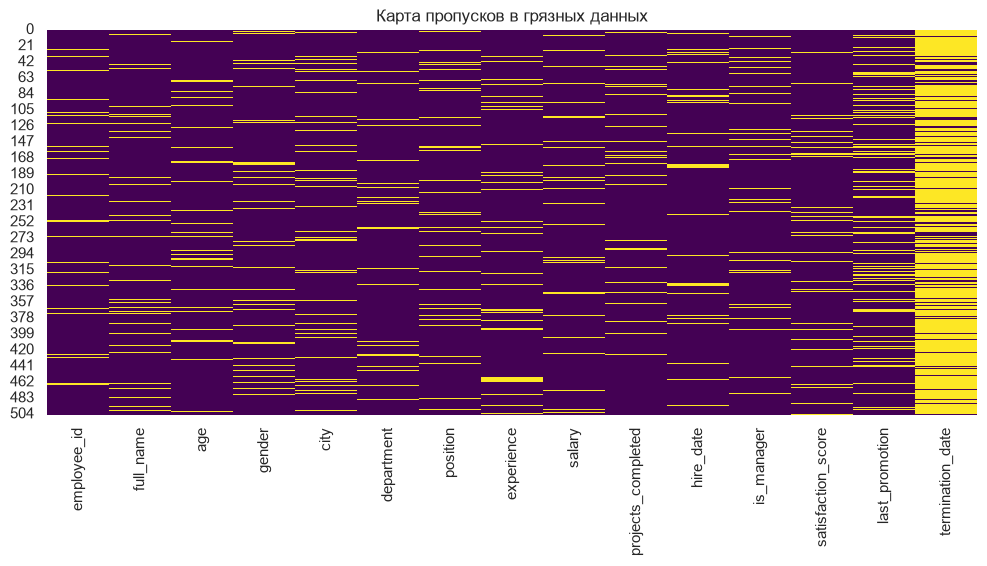

In [4]:
plt.figure(figsize=(12, 5))
sns.heatmap(df_dirty.isna(), cbar=False, cmap="viridis")
plt.title("Карта пропусков в грязных данных")
plt.show()

In [5]:
df = fix_types(df_dirty)

print("Типы после исправления:")
print(df.dtypes)

print("\nПропуски после исправления типов:")
print(df.isna().sum())

print("\nУникальные значения is_manager:")
print(df["is_manager"].value_counts(dropna=False))

print("\nПример salary (первые 5 значений):")
print(df["salary"].head())

Типы после исправления:
employee_id                      str
full_name                        str
age                          float64
gender                           str
city                             str
department                       str
position                         str
experience                   float64
salary                       float64
projects_completed           float64
hire_date             datetime64[us]
is_manager                    object
satisfaction_score           float64
last_promotion        datetime64[us]
termination_date      datetime64[us]
dtype: object

Пропуски после исправления типов:
employee_id            32
full_name              37
age                    42
gender                 41
city                   47
department             30
position               39
experience             42
salary                 35
projects_completed     32
hire_date              39
is_manager             38
satisfaction_score     39
last_promotion         94
terminat

In [6]:
df = normalize_categories(df)

print("Уникальные значения gender:")
print(df["gender"].value_counts(dropna=False))

print("\nТоп-15 городов:")
print(df["city"].value_counts(dropna=False).head(15))

print("\nУникальные значения is_manager:")
print(df["is_manager"].value_counts(dropna=False))

Уникальные значения gender:
gender
Male      242
Female    222
NaN        41
Name: count, dtype: int64

Топ-15 городов:
city
NaN                47
Москва             37
Казань             36
Нижний Новгород    36
Новосибирск        33
Самара             33
Челябинск          33
Воронеж            31
Екатеринбург       30
Санкт-Петербург    30
Ростов-на-Дону     29
Волгоград          28
Уфа                27
Пермь              27
Омск               24
Name: count, dtype: int64

Уникальные значения is_manager:
is_manager
False    433
NaN       38
True      34
Name: count, dtype: int64


In [7]:
print("Полных дубликатов до:", df.duplicated().sum())

df = drop_duplicates(df)

print(f"\nРазмер после удаления дубликатов: {df.shape}")

Полных дубликатов до: 5
Удалено дубликатов: 5

Размер после удаления дубликатов: (500, 15)


In [8]:
print("Пропуски до заполнения:")
print(df.isna().sum())

df = fill_missing(df)

print("\nПропуски после заполнения:")
print(df.isna().sum())
print("\nИтоговый размер:", df.shape)

Пропуски до заполнения:
employee_id            32
full_name              37
age                    42
gender                 40
city                   45
department             29
position               39
experience             41
salary                 35
projects_completed     32
hire_date              39
is_manager             38
satisfaction_score     39
last_promotion         94
termination_date      396
dtype: int64

Пропуски после заполнения:
employee_id            32
full_name              37
age                     0
gender                  0
city                    0
department              0
position                0
experience              0
salary                  0
projects_completed      0
hire_date              39
is_manager              0
satisfaction_score      0
last_promotion         94
termination_date      396
dtype: int64

Итоговый размер: (500, 15)


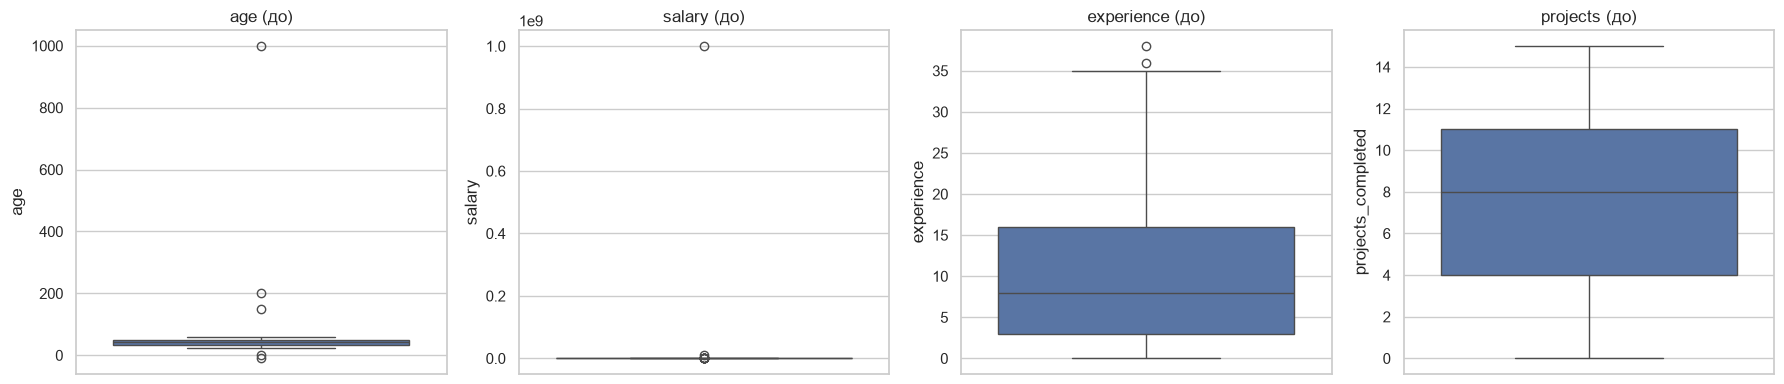

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.boxplot(y=df["age"], ax=axes[0]); axes[0].set_title("age (до)")
sns.boxplot(y=df["salary"], ax=axes[1]); axes[1].set_title("salary (до)")
sns.boxplot(y=df["experience"], ax=axes[2]); axes[2].set_title("experience (до)")
sns.boxplot(y=df["projects_completed"], ax=axes[3]); axes[3].set_title("projects (до)")

plt.tight_layout()
plt.show()

In [10]:
# ---- IQR ----
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1
low_iqr = Q1 - 1.5 * IQR
high_iqr = Q3 + 1.5 * IQR

out_iqr = df[(df["salary"] < low_iqr) | (df["salary"] > high_iqr)]

print(f"IQR: Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
print(f"    Границы: [{low_iqr:.0f}; {high_iqr:.0f}]")
print(f"    Выбросов: {len(out_iqr)}")

# ---- Z-score ----
z_scores = np.abs(stats.zscore(df["salary"]))
out_z = df[z_scores > 3]

print(f"\nZ-score (>3): выбросов = {len(out_z)}")

# ---- Пересечение ----
idx_iqr = set(out_iqr.index)
idx_z = set(out_z.index)
print(f"\nПересечение IQR и Z-score: {len(idx_iqr & idx_z)}")
print(f"Только IQR: {len(idx_iqr - idx_z)}")
print(f"Только Z-score: {len(idx_z - idx_iqr)}")

IQR: Q1=64081, Q3=120821, IQR=56740
    Границы: [-21030; 205931]
    Выбросов: 13

Z-score (>3): выбросов = 1

Пересечение IQR и Z-score: 1
Только IQR: 12
Только Z-score: 0


In [11]:
print("Размер до обработки выбросов:", df.shape)

df = remove_outliers(df)

print("Размер после обработки выбросов:", df.shape)
print("\nСтатистика после обработки:")
print(df[["age", "salary", "experience", "projects_completed"]].describe())

Размер до обработки выбросов: (500, 15)
Размер после обработки выбросов: (494, 15)

Статистика после обработки:
              age         salary  experience  projects_completed
count  494.000000     494.000000  494.000000          494.000000
mean    41.190283   96651.773785   10.469636            7.489879
std     10.706495   41118.557832    8.573397            4.276320
min      0.000000   25910.000000    0.000000            0.000000
25%     33.000000   64862.500000    3.000000            4.000000
50%     43.000000   89207.000000    8.000000            8.000000
75%     50.000000  120649.250000   16.000000           11.000000
max     59.000000  204329.375000   38.000000           15.000000


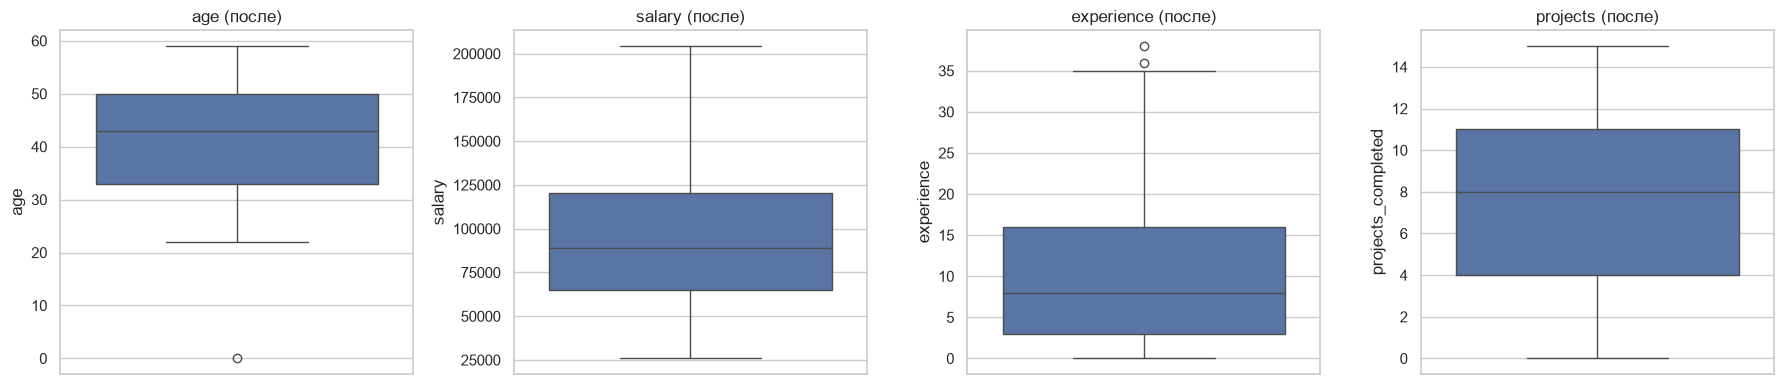

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.boxplot(y=df["age"], ax=axes[0]); axes[0].set_title("age (после)")
sns.boxplot(y=df["salary"], ax=axes[1]); axes[1].set_title("salary (после)")
sns.boxplot(y=df["experience"], ax=axes[2]); axes[2].set_title("experience (после)")
sns.boxplot(y=df["projects_completed"], ax=axes[3]); axes[3].set_title("projects (после)")

plt.tight_layout()
plt.show()

In [13]:
print("=" * 60)
print("СРАВНЕНИЕ ДО И ПОСЛЕ")
print("=" * 60)

print(f"\nРазмеры:")
print(f"  Грязные:      {df_dirty.shape}")
print(f"  Очищенные:    {df.shape}")
print(f"  Эталон:       {df_reference.shape}")

print(f"\nПропуски:")
print(f"  Грязные:      {df_dirty.isna().sum().sum()}")
print(f"  Очищенные:    {df.isna().sum().sum()}")

print(f"\nСредняя зарплата:")
print(f"  Грязные:      {pd.to_numeric(df_dirty['salary'], errors='coerce').mean():.0f}")
print(f"  Очищенные:    {df['salary'].mean():.0f}")
print(f"  Эталон:       {df_reference['salary'].mean():.0f}")

print(f"\nСредний возраст:")
print(f"  Грязные:      {pd.to_numeric(df_dirty['age'], errors='coerce').mean():.1f}")
print(f"  Очищенные:    {df['age'].mean():.1f}")
print(f"  Эталон:       {df_reference['age'].mean():.1f}")

СРАВНЕНИЕ ДО И ПОСЛЕ

Размеры:
  Грязные:      (505, 15)
  Очищенные:    (494, 15)
  Эталон:       (500, 15)

Пропуски:
  Грязные:      984
  Очищенные:    592

Средняя зарплата:
  Грязные:      2269251
  Очищенные:    96652
  Эталон:       97881

Средний возраст:
  Грязные:      43.6
  Очищенные:    41.2
  Эталон:       41.3


In [14]:
OUTPUT = "../data/cleaned_dataset.xlsx"
df.to_excel(OUTPUT, index=False)
print(f"✅ Сохранено: {OUTPUT}")
print(f"   Размер: {df.shape}")

✅ Сохранено: ../data/cleaned_dataset.xlsx
   Размер: (494, 15)


In [15]:
df_check = pd.read_excel("../data/cleaned_dataset.xlsx")
print("Проверка загрузки сохранённого файла:")
print(f"  Размер: {df_check.shape}")
print(f"  Пропуски: {df_check.isna().sum().sum()}")
print(f"  Столбцы: {list(df_check.columns)}")

Проверка загрузки сохранённого файла:
  Размер: (494, 15)
  Пропуски: 592
  Столбцы: ['employee_id', 'full_name', 'age', 'gender', 'city', 'department', 'position', 'experience', 'salary', 'projects_completed', 'hire_date', 'is_manager', 'satisfaction_score', 'last_promotion', 'termination_date']
